# Label distribution in main caption and alt captions

This notebook loads label files from the current `labels` folder, extracts `main_caption` and `alt_captions`, and visualizes the label frequency distribution for both caption types.

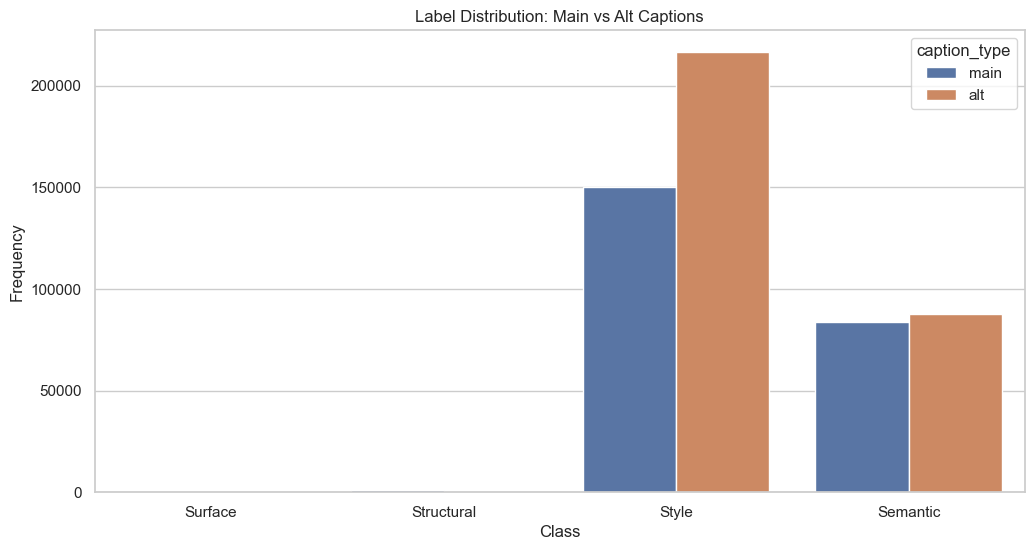

In [6]:
from pathlib import Path
import json
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set(style="whitegrid")

# load files directly
with open("main_caption_classes.json", "r") as f:
    main_caption_classes = json.load(f)

with open("alt_caption_classes.json", "r") as f:
    alt_caption_classes = json.load(f)

# flatten
main_labels = [label for caption in main_caption_classes for label in caption]
alt_labels = [label for caption in alt_caption_classes for label in caption]

# count
main_counts = Counter(main_labels)
alt_counts = Counter(alt_labels)

# convert to dataframe
combined = []

for label, count in main_counts.items():
    combined.append({
        "label": label,
        "caption_type": "main",
        "count": count
    })

for label, count in alt_counts.items():
    combined.append({
        "label": label,
        "caption_type": "alt",
        "count": count
    })

combined_df = pd.DataFrame(combined)

# plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=combined_df,
    x="label",
    y="count",
    hue="caption_type"
)

plt.xticks([0,1,2,3], [
    "Surface",
    "Structural",
    "Style",
    "Semantic"
])

plt.title("Label Distribution: Main vs Alt Captions")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

In [ ]:
import json
from collections import defaultdict
import random

# load original training data
with open("C:\\Users\\Theodore da Cunha\\Desktop\\project\\research\\language_alignment\\data\\MusicBench_train.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)

# load class labels
with open("main_caption_classes.json", "r") as f:
    main_caption_classes = json.load(f)

with open("alt_caption_classes.json", "r") as f:
    alt_caption_classes = json.load(f)

# split captions into sentences
split_main_captions = [
    [s.strip() for s in item["main_caption"].split(".") if s.strip()]
    for item in train_data
]

split_alt_captions = [
    [s.strip() for s in item["alt_caption"].split(".") if s.strip()]
    for item in train_data
]

label_names = {
    0: "Instrumentation and timbre",
    1: "Tempo rhythm beat meter",
    2: "Key chords harmony progression",
    3: "Genre style production",
    4: "Emotion mood feeling",
    5: "Scene imagery context"
}

# group sentences by label
main_examples = defaultdict(list)
alt_examples = defaultdict(list)

for caption_sentences, caption_labels in zip(split_main_captions, main_caption_classes):
    for sentence, label in zip(caption_sentences, caption_labels):
        main_examples[label].append(sentence)

for caption_sentences, caption_labels in zip(split_alt_captions, alt_caption_classes):
    for sentence, label in zip(caption_sentences, caption_labels):
        alt_examples[label].append(sentence)

# show random examples
for label in range(6):
    print("=" * 60)
    print(f"LABEL {label}: {label_names[label]}")
    print("\nMAIN CAPTION EXAMPLES:")
    for example in random.sample(main_examples[label], min(10, len(main_examples[label]))):
        print("-", example)

    print("\nALT CAPTION EXAMPLES:")
    for example in random.sample(alt_examples[label], min(10, len(alt_examples[label]))):
        print("-", example)
    print()

LABEL 0: Surface acoustic property

MAIN CAPTION EXAMPLES:
- A photo is heard being taken in the background
- Since this is an amateur recording, the finger tapping sounds can be heard as well
- This instrumental track in G minor begins with a catchy synth melody and percussion, which pauses to allow for the sound of water splashing in
- Shimmering cymbals add a glimmering layer on top, complemented with an electric guitar that captivates with an irresistible melody
- The sound of running water and a person running can be heard, along with the opening and closing of a squeaky door
- There is also the sound of a non-steel object being placed on a surface
- Another non-steel object is placed on a surface producing a distinct sound
- This song would likely be heard in a countryside home
- This is a song you would hear at a hotel lobby in Hawaii
- This melodic track, likely from a PC or mobile game, has a unique percussion element: the sound of pages being turned at regular intervals

ALT 